# Examen Machine Learning 1

* **Nombre del dataset:** California Housing Dataset.
* **Fuente:** Scikit-learn (fetch_california_housing) / StatLib.
* **URL:** https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html
* **Número de filas:** 20,640
* **Número de columnas:** 9 (8 predictoras, 1 objetivo)
* **Variable objetivo:** `target` (Valor mediano de las viviendas).
* **Tipo de tarea:** Regresión.

In [13]:
# Importaación de Librerías
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Crear carpeta para exportar figuras
os.makedirs("figuras", exist_ok=True)

# Configuraciín de estilos visual estandar para gráficos
sns.set_theme(style="whitegrid")

In [14]:
# carga de dataset y revision inicial
df = pd.read_excel("fetch_california_housing.xlsx") 

print("Dimensiones (filas, columnas):", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\mIniformacion general del dataset:")
df.info()

print("\nPrimeras 5 filas:")
display(df.head())



<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
C:\Users\orell\AppData\Local\Temp\ipykernel_16112\4289276237.py:6: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  print("\mIniformacion general del dataset:")


Dimensiones (filas, columnas): (20640, 9)

Tipos de datos:
 MedInc        float64
HouseAge        int64
AveRooms      float64
AveBedrms     float64
Population      int64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object
\mIniformacion general del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  int64  
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  int64  
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(7), int64(2)
memory usage: 1.4 MB

Primeras 5 filas:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41,6.984127,1.023810,322,2.555556,37.88,-122.23,4.526
1,8.3014,21,6.238137,0.971880,2401,2.109842,37.86,-122.22,3.585
2,7.2574,52,8.288136,1.073446,496,2.802260,37.85,-122.24,3.521
3,5.6431,52,5.817352,1.073059,558,2.547945,37.85,-122.25,3.413
4,3.8462,52,6.281853,1.081081,565,2.181467,37.85,-122.25,3.422


porcentaje de valores nulos por columna:
 MedInc        0.0
HouseAge      0.0
AveRooms      0.0
AveBedrms     0.0
Population    0.0
AveOccup      0.0
Latitude      0.0
Longitude     0.0
target        0.0
dtype: float64


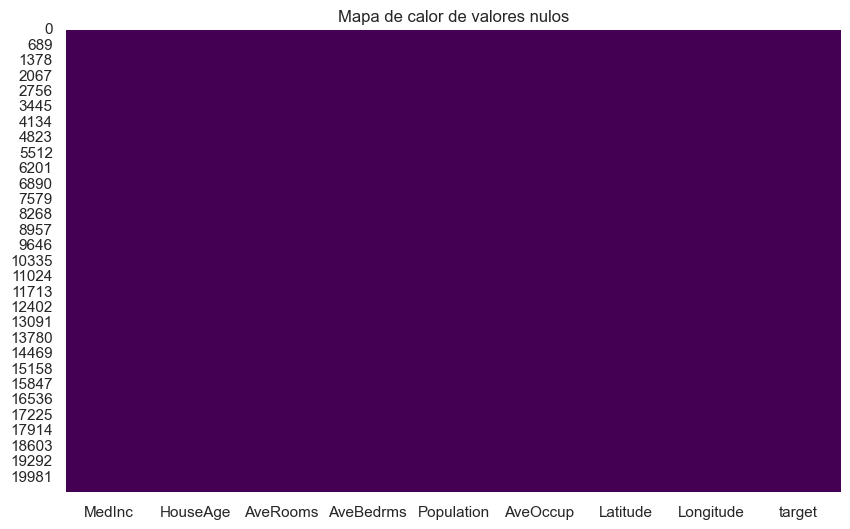

In [15]:
# Analisis de valores faltantes
# Calculamos el porcentaje de valores nulos por columna
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100
print("porcentaje de valores nulos por columna:\n", porcentaje_nulos)

# Visualización con Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Mapa de calor de valores nulos")
# Guardamos la figura
plt.savefig("figuras/heatmap_valores_nulos.png", dpi=150)
plt.show()


### Justificación de Valores Faltantes
Tal como lo demuestra el análisis de porcentaje y el Heatmap, el dataset **no contiene valores nulos** en ninguna de sus columnas. Pro lo tanto no es necesario aplicar tecnicas de imputación (mediana,moda,KNN) ni eliminar columnas por falta de datos.


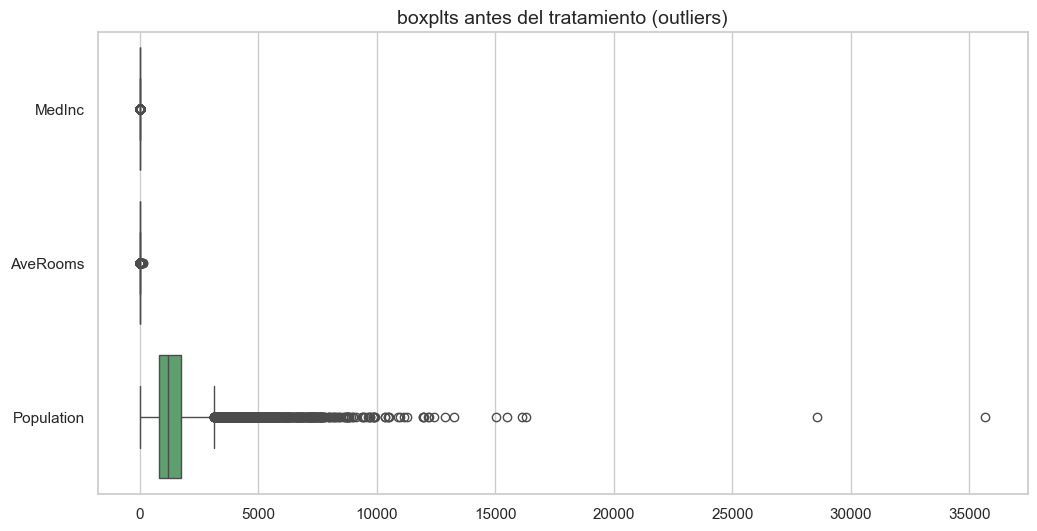

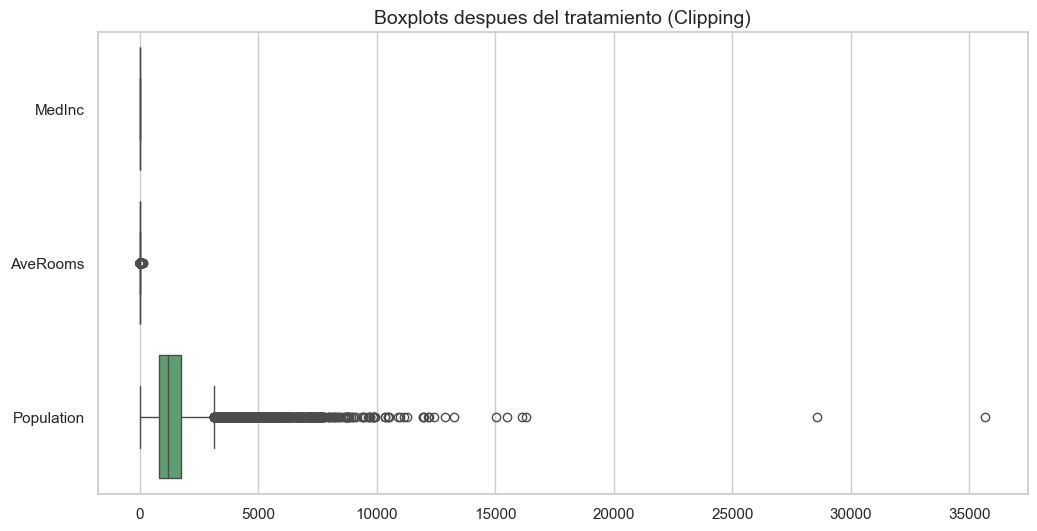

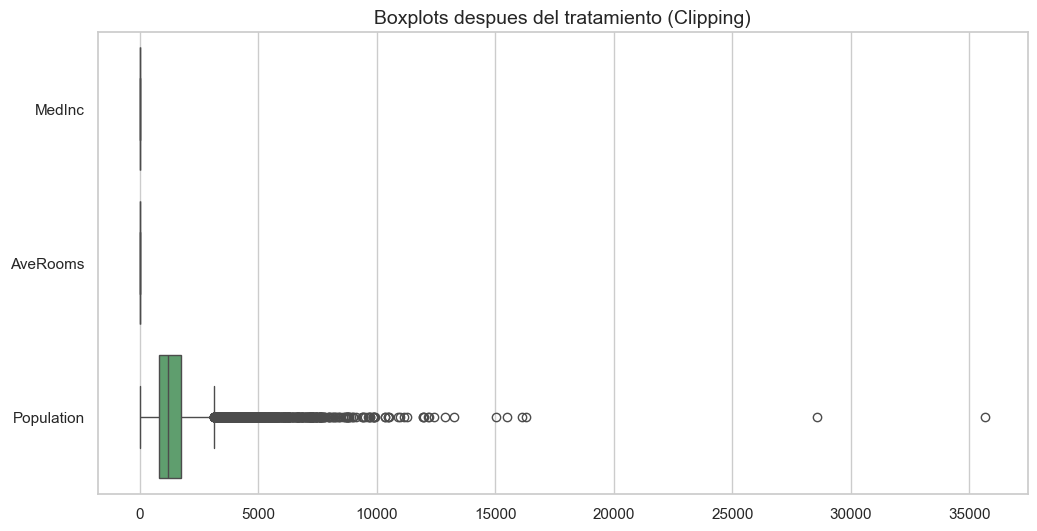

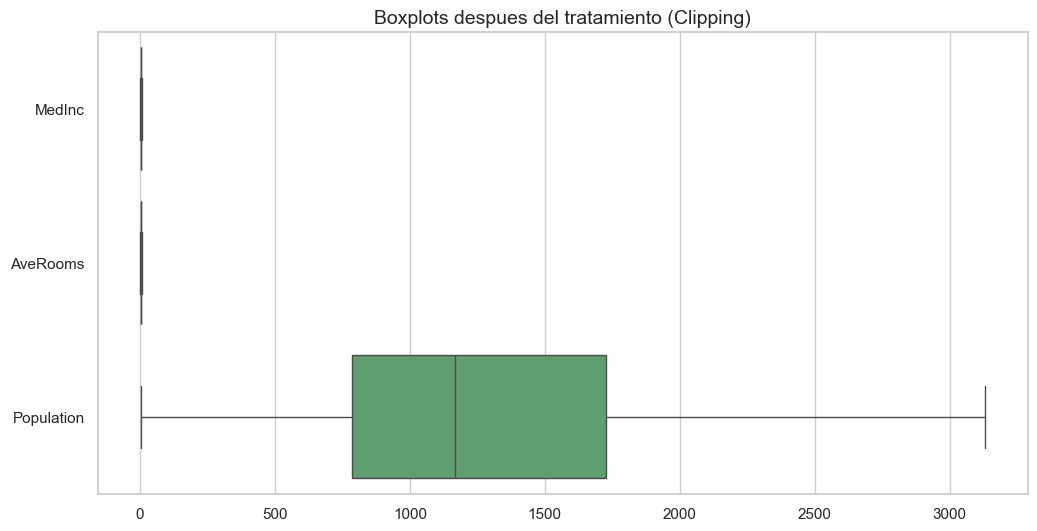

In [16]:
# detección de Outliers (metodo IQR) en variables clave
# Seleccionamois variables suceptibles a valores extremos
variables_clave = ['MedInc', 'AveRooms', 'Population']

# Boxplot antes del tratamiento
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[variables_clave], orient="h")
plt.title('boxplts antes del tratamiento (outliers)', fontsize=14)
plt.savefig('figuras/boxplots_antes_iqr.png', dpi=150)
plt.show()

# Tratamiento: Clipping (Winsorizing) basado en IQR
for col in variables_clave:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Aplicamos limite (cap) a los valores en vez de eliminarlos
    df[col] = np.clip(df[col], limite_inferior, limite_superior)

    # Boxplots después del tratamiento
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[variables_clave], orient="h")
    plt.title('Boxplots despues del tratamiento (Clipping)', fontsize=14)
    plt.savefig('figures/boxplots_despues_iqr.png', dpi=150)
    plt.show()


### Justificación del Tratamiento de Outliers
Se optó por **imputar (clipping)** los outliers limitando los valores a los bigotes inferior y superior calculados por el método IQR. Se descartó la opción de *eliminar* las filas atípicas, ya que variables como `AveRooms` o `Population` contienen colas pesadas reales de la geografía californiana; eliminarlas habría significado una pérdida masiva de observaciones valiosas para el entrenamiento.

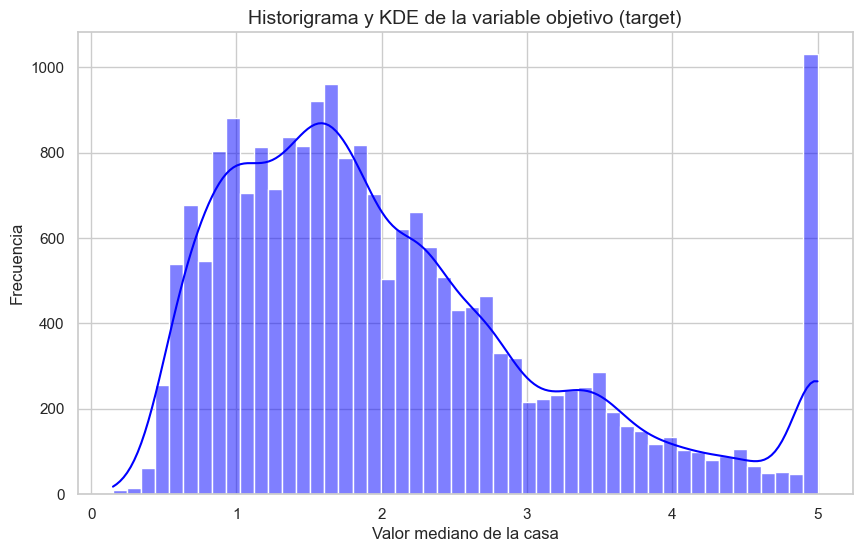

Asimetría de la variable objetivo target: 0.9778
La asimetria es menor o igual a 1.0. No se aplicara transformación logaritmica.


In [18]:
# Regresión: Distribucion de la variable objetivo
plt.figure(figsize=(10, 6))
sns.histplot(df['target'], kde=True, bins=50, color='blue')
plt.title('Historigrama y KDE de la variable objetivo (target)', fontsize=14)
plt.xlabel('Valor mediano de la casa')
plt.ylabel('Frecuencia')
plt.savefig('figuras/target_historigrama.png', dpi=150)
plt.show()

# Calculo de la asimetria
skewness = df['target'].skew()
print(f"Asimetría de la variable objetivo target: {skewness:.4f}")

if skewness > 1.0:
    print("La asimetria es mayo a 1.0. Se aplicara transformación logaritmica (np.Log1p).")
else:
    print("La asimetria es menor o igual a 1.0. No se aplicara transformación logaritmica.")


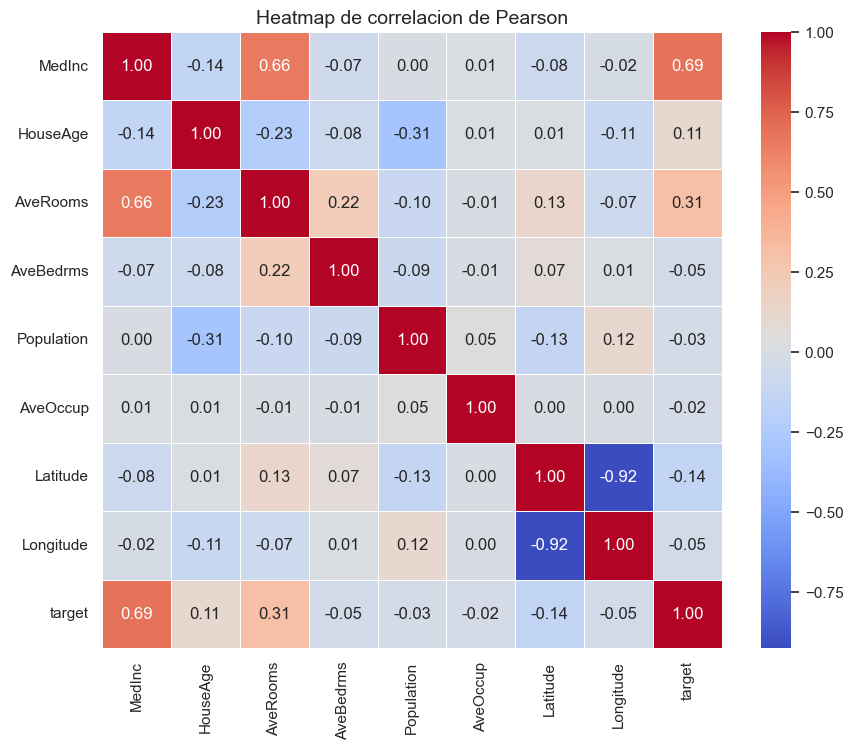

Las 5 variables más correlacionadas con la variable objetivo (target):
 MedInc       0.689001
AveRooms     0.311003
Latitude     0.144160
HouseAge     0.105623
AveBedrms    0.046701
Name: target, dtype: float64

Análisis de multicolinealidad entre predictores (r > 0.85):
Multicolinealidad detectada entre Longitude y Latitude: r = -0.92


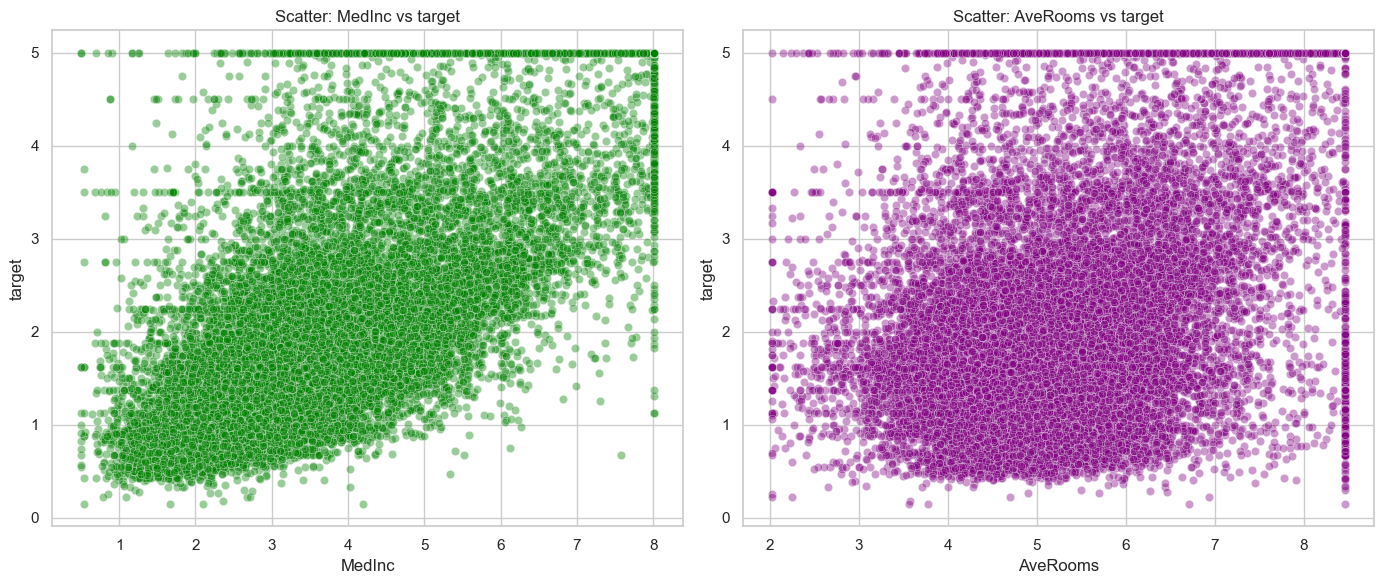

<Figure size 1000x1000 with 0 Axes>

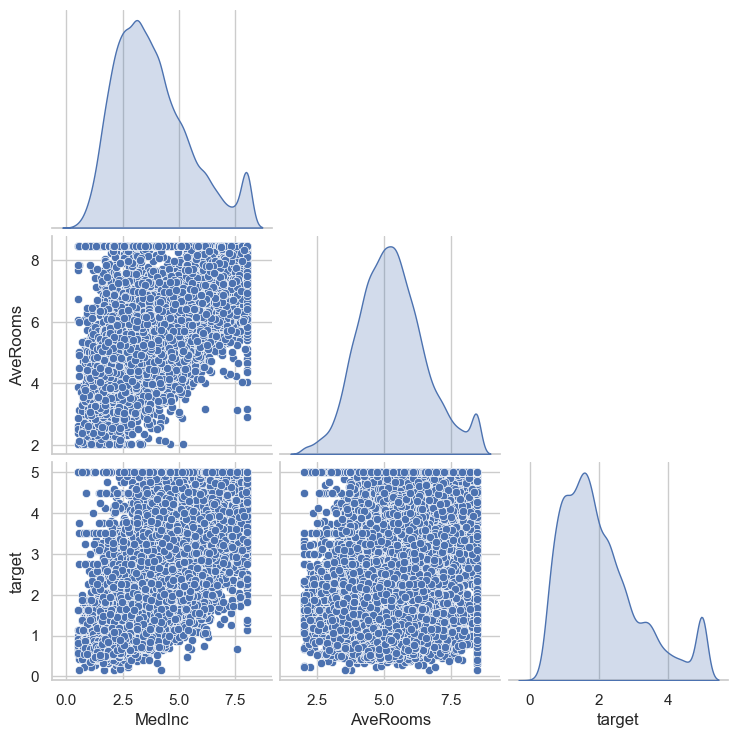

In [19]:
# Visualizaciones exploratorias y correlaciones

# Heatmap de correlación de pearson
plt.figure(figsize=(10, 8))
matriz_corr = df.corr()
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap de correlacion de Pearson', fontsize=14)
plt.savefig('figuras/heatmap_correlacion.png', dpi=150)
plt.show()

# Identificar las variables mas correlaciones con el target
correlaciones_target = matriz_corr['target'].abs().sort_values(ascending=False)
top_5_vars = correlaciones_target[1:6]  # Excluimos el index 0 
print("Las 5 variables más correlacionadas con la variable objetivo (target):\n", top_5_vars)

# Reporte de multicolinealidad (r > 0.85)
print("\nAnálisis de multicolinealidad entre predictores (r > 0.85):")
hay_multicolinealidad = False
for i in range(len(matriz_corr.columns)):
    for j in range(i):
        # Excluimos la variable objetivo del análisis de multicolinealidad
        if matriz_corr.columns[i] != 'target' and matriz_corr.columns[j] != 'target':
            if abs(matriz_corr.iloc[i, j]) > 0.85:
                hay_multicolinealidad = True
                print(f"Multicolinealidad detectada entre {matriz_corr.columns[i]} y {matriz_corr.columns[j]}: r = {matriz_corr.iloc[i, j]:.2f}")

if not hay_multicolinealidad:
     print("No se detectó multicolinealidad significativa entre las variables predictoras.")


# Scatter de las 2 variables mas correlacionadas
var_1 = top_5_vars.index[0] # MedInc
var_2 = top_5_vars.index[1] # AveRooms

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.scatterplot(x=df[var_1], y=df['target'], alpha=0.4, color='green')
plt.title(f'Scatter: {var_1} vs target')
plt.xlabel(var_1)
plt.ylabel('target')

plt.subplot(1, 2, 2)
sns.scatterplot(x=df[var_2], y=df['target'], alpha=0.4, color='purple')
plt.title(f'Scatter: {var_2} vs target')
plt.xlabel(var_2)
plt.ylabel('target')

plt.savefig('figuras/scatter_top2.png', dpi=150)
plt.tight_layout()
plt.show()

# Pairplot adicional
# Tomamos el target y las 2 variables mas influyentes
plt.figure(figsize=(10, 10))
sns.pairplot(df[[var_1, var_2, 'target']], corner=True, diag_kind='kde')
# Guardamos la figura generada por pairplot.
plt.savefig('figuras/pairplot_adicional.png', dpi=150)
plt.show()

In [ ]:
# division de datos en train/test antes e cualquier transformación
from sklearn.model_selection import train_test_split

